In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from herculens.Coordinates.pixel_grid import PixelGrid
from herculens.Instrument.noise import Noise
from herculens.Instrument.psf import PSF
from herculens.MassModel.mass_model import MassModel
from herculens.LightModel.light_model import LightModel
from herculens.LensImage.lens_image import LensImage

set up the coordinate grid

In [ ]:
nx, ny = (101, 101) # number of pixels per side
pix_scale = 0.05 # physical width of pixel (arcsec)

In [ ]:
# what is the physical coordinate of the (0, 0) corner pixel?
half_size_x = nx*pix_scale/2
half_size_y = ny*pix_scale/2
ra_at_xy_0 = -half_size_x + pix_scale/2
dec_at_xy_0 = -half_size_y + pix_scale/2

transform_pix2angle = pix_scale*np.eye(2)
kwargs_pixel = {
    'nx': nx,
    'ny': ny,
    'ra_at_xy_0': ra_at_xy_0,
    'dec_at_xy_0': dec_at_xy_0,
    'transform_pix2angle': transform_pix2angle
}

# herculens' pixel grid class handles everything
pixel_grid = PixelGrid(**kwargs_pixel)

# useful things we might need from it
xgrid, ygrid = pixel_grid.pixel_coordinates
x_axis = xgrid[0]
y_axis = ygrid[:, 0]
extent = pixel_grid.extent
x_grid, y_grid = np.meshgrid(x_axis, y_axis)   

set up a telescope

In [ ]:
exposure_time = 600 
background_rms = 0.01
fwhm = 0.1

noise = Noise(nx, ny, background_rms=background_rms, exposure_time=exposure_time)
psf = PSF(psf_type='GAUSSIAN', fwhm=fwhm, pixel_size=pix_scale)

set up the lens

In [ ]:
# what's included

from herculens.MassModel.mass_model_base import SUPPORTED_MODELS as available_mass_models
from herculens.LightModel.light_model_base import SUPPORTED_MODELS as available_light_models
print(f'available mass models : {available_mass_models}')
print(f'available light models : {available_light_models}')

available mass models : ['EPL', 'NIE', 'SIE', 'SIS', 'DPIE', 'PIEMD', 'GAUSSIAN', 'POINT_MASS', 'SHEAR', 'SHEAR_GAMMA_PSI', 'MULTIPOLE', 'PIXELATED', 'PIXELATED_DIRAC', 'PIXELATED_FIXED']
available light models : ['SERSIC', 'SERSIC_ELLIPSE', 'SERSIC_SUPERELLIPSE', 'GAUSSIAN', 'GAUSSIAN_ELLIPSE', 'MULTIPOLE', 'PIXELATED', 'UNIFORM', 'SHAPELETS']


In [ ]:
lens_mass_model = MassModel(['EPL', 'SHEAR']) # add deflection angles together: elliptical power law with external shear
lens_light_model = LightModel(['SERSIC_ELLIPSE']) # elliptical sersic profile
source_light_model = LightModel(['SERSIC_ELLIPSE']) 

mass model

In [ ]:
lens_EPL_kwargs = {
    'theta_E': 1.5,
    'gamma': 2.05,
    'e1': 0.0,
    'e2': 0.1,
    'center_x': 0.0,
    'center_y': 0.0
}
lens_shear_kwargs = {
    'gamma1': 0.0,
    'gamma2': -0.03,
    'ra_0': lens_EPL_kwargs['center_x'],
    'dec_0': lens_EPL_kwargs['center_y'],
}
lens_mass_kwargs = [lens_EPL_kwargs, lens_shear_kwargs]

# convergence
lens_kappa = lens_mass_model.kappa(x=x_grid, y=y_grid, kwargs=lens_mass_kwargs)

# shear
lens_gamma = lens_mass_model.gamma(x=x_grid, y=y_grid, kwargs=lens_mass_kwargs)
lens_gamma_1, lens_gamma_2 = lens_gamma

# magnification
lens_mu = 1/lens_mass_model.inverse_magnification(x=x_grid, y=y_grid, kwargs=lens_mass_kwargs)

# deflection angle
lens_alpha = lens_mass_model.alpha(x=x_grid, y=y_grid, kwargs=lens_mass_kwargs)
lens_alpha_x, lens_alpha_y = lens_alpha

Text(0.5, 1.0, 'magnification')

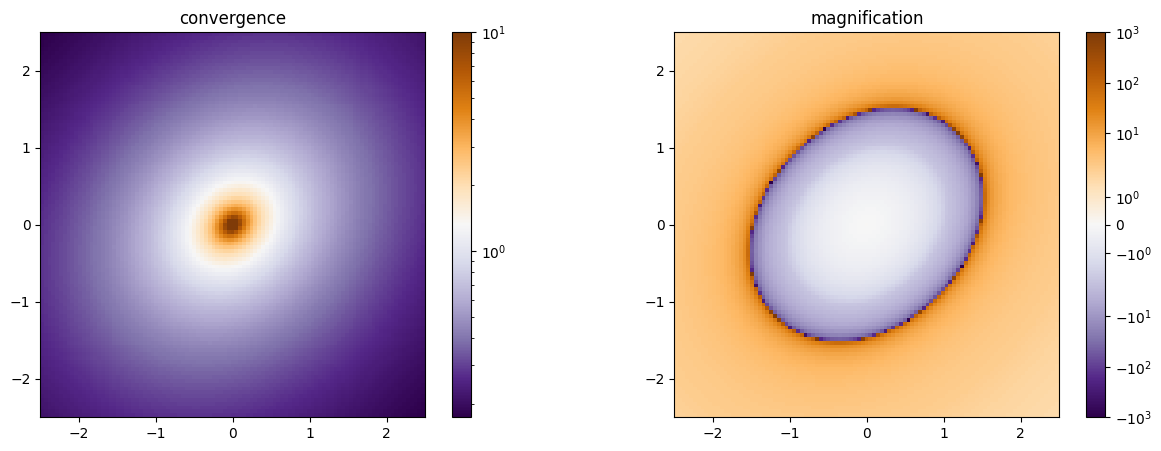

In [ ]:
# what do the mass distribution and the magnification look like?

plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.imshow(lens_kappa, origin='lower', cmap='PuOr_r', norm='log', extent=extent, vmax=10)
plt.colorbar()
plt.title('convergence')

plt.subplot(122)
plt.imshow(lens_mu, origin='lower', cmap='PuOr_r',  norm='symlog', extent=extent, vmin=-1e3, vmax=1e3)
plt.colorbar()
plt.title('magnification')

light model

In [ ]:
lens_sersic_kwargs = {
    'amp': 1.0,
    'R_sersic': 0.5,
    'n_sersic': 4.0, # n=4: de Vaucouleurs profile
    'e1': 0.0,
    'e2': 0.1,
    'center_x': 0.0,
    'center_y': 0.0
}

lens_light_kwargs = [lens_sersic_kwargs]

In [ ]:
source_sersic_kwargs = {
    'amp': 1.0,
    'R_sersic': 0.1,
    'n_sersic': 1.0, # n=1: exponential profile
    'e1': 0.0,
    'e2': 0.1,
    'center_x': 0.0,
    'center_y': 0.0
}

source_light_kwargs = [source_sersic_kwargs]

In [ ]:
lens_light_prof = lens_light_model.surface_brightness(x=x_grid, y=y_grid, kwargs=lens_light_kwargs)
source_light_prof = source_light_model.surface_brightness(x=x_grid, y=y_grid, kwargs=source_light_kwargs) # bare in mind that this is computed from image plane coordinates

Text(0.5, 1.0, 'source light')

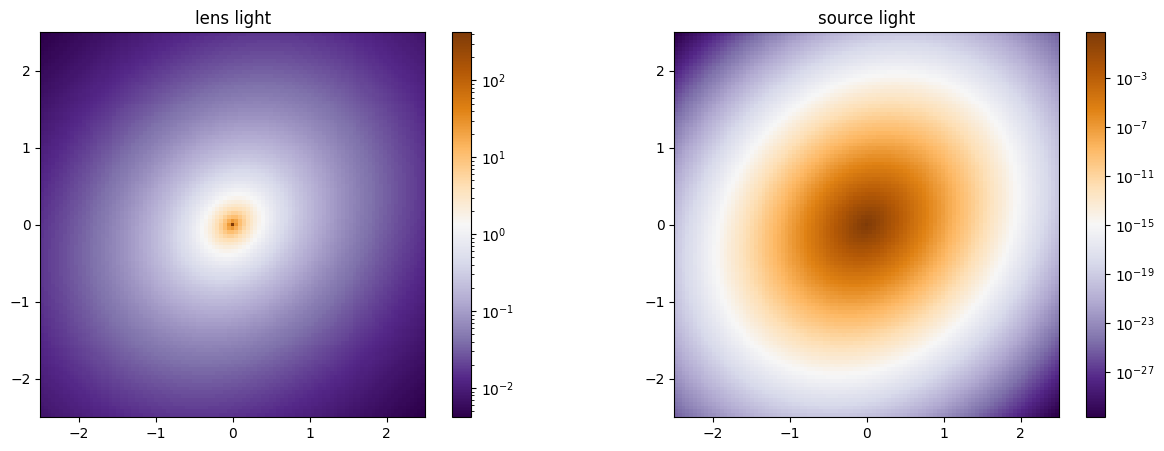

In [ ]:
# what do the lens and source look like?

plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.imshow(lens_light_prof, origin='lower', cmap='PuOr_r', norm='log', extent=extent)
plt.colorbar()
plt.title('lens light')

plt.subplot(122)
plt.imshow(source_light_prof, origin='lower', cmap='PuOr_r',  norm='log', extent=extent)
plt.colorbar()
plt.title('source light')

fun stuff

In [ ]:
# handles stuff that needs ray tracing
lens_image = LensImage(
    grid_class=pixel_grid,
    psf_class=psf,
    noise_class=noise,
    lens_mass_model_class=lens_mass_model,
    lens_light_model_class=lens_light_model,
    source_model_class=source_light_model
)

lens_image.model?

Signature:
lens_image.model(
    kwargs_lens=None,
    kwargs_source=None,
    kwargs_lens_light=None,
    kwargs_point_source=None,
    unconvolved=False,
    supersampled=False,
    source_add=True,
    lens_light_add=True,
    point_source_add=True,
    k_lens=None,
    k_source=None,
    k_lens_light=None,
    k_point_source=None,
    adapted_source_pixels_coords=None,
    return_source_pixels_coords=False,
)
Docstring:
Create the 2D model image from parameter values.
Note: due to JIT compilation, the first call to this method will be slower.

:param kwargs_lens: list of keyword arguments corresponding to the superposition of different lens profiles
:param kwargs_source: list of keyword arguments corresponding to the superposition of different source light profiles
:param kwargs_lens_light: list of keyword arguments corresponding to different lens light surface brightness profiles
:param kwargs_point_source: keyword arguments corresponding to "other" parameters, such as external sh

In [ ]:
model_image = lens_image.model(unconvolved=True, kwargs_lens=lens_mass_kwargs, kwargs_source=source_light_kwargs, kwargs_lens_light=lens_light_kwargs)

Text(0.5, 1.0, 'a model lens')

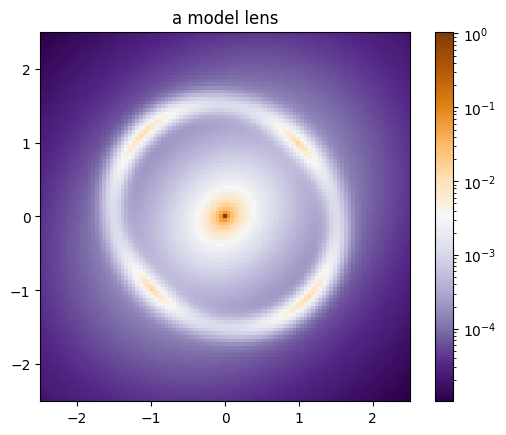

In [ ]:
plt.imshow(model_image, origin='lower', cmap='PuOr_r',  extent=extent, norm='log')
plt.colorbar()
plt.title('a model lens')

In [ ]:
model_image = lens_image.model(unconvolved=False, kwargs_lens=lens_mass_kwargs, kwargs_source=source_light_kwargs, kwargs_lens_light=lens_light_kwargs)

Text(0.5, 1.0, 'a model lens')

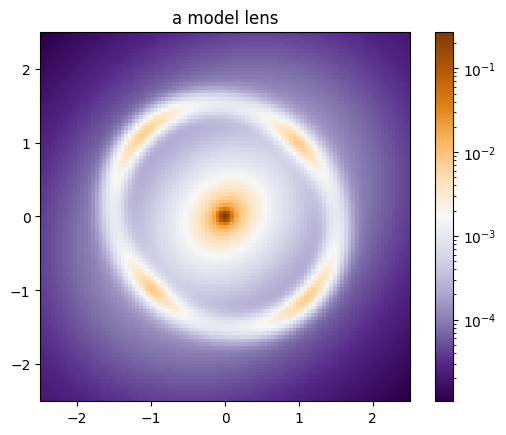

In [ ]:
plt.imshow(model_image, origin='lower', cmap='PuOr_r',  extent=extent, norm='log')
plt.colorbar()
plt.title('a model lens')

In [ ]:
model_image = lens_image.simulation(unconvolved=False, kwargs_lens=lens_mass_kwargs, kwargs_source=source_light_kwargs, kwargs_lens_light=lens_light_kwargs)

Text(0.5, 1.0, 'a model lens')

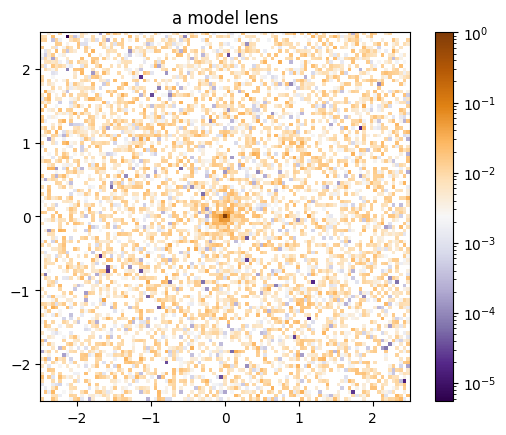

In [ ]:
plt.imshow(model_image, origin='lower', cmap='PuOr_r',  extent=extent, norm='log')
plt.colorbar()
plt.title('a model lens')